# Task 3: Heart Disease Prediction

### 🎯 Objective
Build a model to predict heart disease using patient health data.

### 📊 Dataset
Heart Disease UCI Dataset (Kaggle)

### 📌 Instructions

Load and inspect the dataset (.head(), .info(), .describe())
Clean data (handle missing values, encode categories if needed)
Perform EDA:
Target distribution
Correlation heatmap
Histograms and box plots
Train a classification model (Logistic Regression or Decision Tree)
Evaluate using:
Accuracy
Confusion Matrix
ROC-AUC Score
Identify important features affecting prediction

### 📈 Skills

Multiclass classification using logistic regression, 
Data preprocessing & EDA, 
Model evaluation (ROC, confusion matrix) and 
Feature importance analysis


In [1]:
# !pip install numpy
# !pip install matplotlib
# !pip install pandas
# !pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("heart_disease_uci.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [4]:
#To check if there are any nan values
df.isna()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
916,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False
917,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
918,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False


In [5]:
#Counting the number of rown containing null values
row_count = df.isnull().any(axis=1).sum()
row_count

np.int64(621)

The number of rows containg nan values are greater so we cannot remove them as we could loss potential patterns. That's why we have to apply some other technique.

In [6]:
#Replacing the NaN values with median values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_imputer = IterativeImputer(random_state=0)
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,460.500000,53.510870,132.406419,198.794342,136.367119,0.890959,0.720684,0.995652
std,265.725422,9.424685,18.516892,109.153865,25.652294,1.065965,0.714724,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,-0.467855,0.000000
25%,230.750000,47.000000,120.000000,175.000000,118.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,222.000000,138.000000,0.600000,0.621636,1.000000
75%,690.250000,60.000000,140.000000,267.000000,156.000000,1.500000,1.032257,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
#Converting the categorical data into numerical
cat_cols = df.select_dtypes(include=['object']).columns
label_encoder = LabelEncoder()
for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1.0,63.0,1,0,3,145.000000,233.0,1,0,150.000000,0,2.300000,0,0.000000,0,0.0
1,2.0,67.0,1,0,0,160.000000,286.0,0,0,108.000000,1,1.500000,1,3.000000,1,2.0
2,3.0,67.0,1,0,0,120.000000,229.0,0,0,129.000000,1,2.600000,1,2.000000,2,1.0
3,4.0,37.0,1,0,2,130.000000,250.0,0,1,187.000000,0,3.500000,0,0.000000,1,0.0
4,5.0,41.0,0,0,1,130.000000,204.0,0,0,172.000000,0,1.400000,2,0.000000,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916.0,54.0,0,3,0,127.000000,333.0,1,2,154.000000,0,0.000000,1,0.988755,1,1.0
916,917.0,62.0,1,3,3,136.556831,139.0,0,2,117.195494,0,0.459087,1,0.754967,1,0.0
917,918.0,55.0,1,3,0,122.000000,223.0,1,2,100.000000,0,0.000000,1,1.212196,0,2.0
918,919.0,58.0,1,3,0,141.063635,385.0,1,0,121.002264,0,0.767936,1,0.744965,1,0.0


In [9]:
df.corr()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,1.000000,0.239301,0.280053,0.949062,-0.189430,0.071394,-0.380278,0.148983,0.479012,-0.493261,0.166239,0.061291,-0.305000,0.321451,-0.169764,0.273552
age,0.239301,1.000000,0.056889,0.235076,-0.076519,0.255053,-0.091309,0.219915,-0.006652,-0.388086,0.160910,0.263955,-0.077087,0.581698,0.101109,0.339596
sex,0.280053,0.056889,1.000000,0.285734,-0.125933,0.008585,-0.197816,0.075370,0.072160,-0.196574,0.155204,0.108950,-0.105805,0.186482,0.076023,0.259342
dataset,0.949062,0.235076,0.285734,1.000000,-0.150334,0.042844,-0.419013,0.170110,0.460189,-0.446010,0.129326,0.063993,-0.297152,0.314893,-0.146806,0.276203
cp,-0.189430,-0.076519,-0.125933,-0.150334,1.000000,-0.018799,0.066731,0.006370,-0.070150,0.273617,-0.360513,-0.175002,0.113415,-0.209417,-0.097099,-0.314518
trestbps,0.071394,0.255053,0.008585,0.042844,-0.018799,1.000000,0.099903,0.161437,0.024531,-0.116791,0.136465,0.167478,-0.056725,0.104541,0.059330,0.126096
chol,-0.380278,-0.091309,-0.197816,-0.419013,0.066731,0.099903,1.000000,0.086006,-0.197248,0.227202,-0.032483,0.051425,0.036582,-0.133356,-0.051164,-0.233097
fbs,0.148983,0.219915,0.075370,0.170110,0.006370,0.161437,0.086006,1.000000,0.025788,-0.064898,-0.003475,0.067552,-0.070830,0.210364,-0.005670,0.129539
restecg,0.479012,-0.006652,0.072160,0.460189,-0.070150,0.024531,-0.197248,0.025788,1.000000,-0.191973,0.026067,-0.016293,-0.128925,0.036161,-0.169442,0.034603
thalch,-0.493261,-0.388086,-0.196574,-0.446010,0.273617,-0.116791,0.227202,-0.064898,-0.191973,1.000000,-0.307872,-0.163636,0.299315,-0.341484,-0.040627,-0.372838


<Axes: xlabel='num', ylabel='count'>

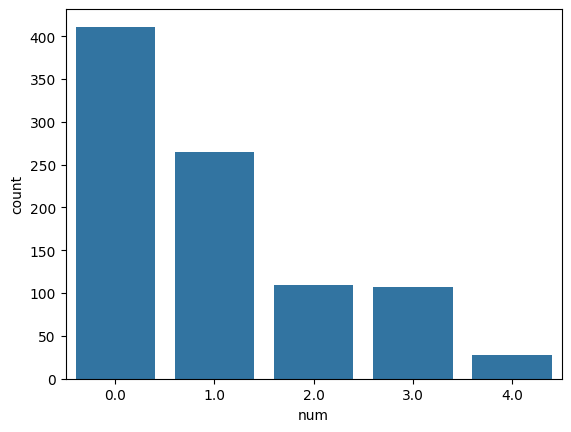

In [10]:
sns.countplot(x="num", data=df)

In [11]:
df = df.drop(["id"], axis=1)
df

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63.0,1,0,3,145.000000,233.0,1,0,150.000000,0,2.300000,0,0.000000,0,0.0
1,67.0,1,0,0,160.000000,286.0,0,0,108.000000,1,1.500000,1,3.000000,1,2.0
2,67.0,1,0,0,120.000000,229.0,0,0,129.000000,1,2.600000,1,2.000000,2,1.0
3,37.0,1,0,2,130.000000,250.0,0,1,187.000000,0,3.500000,0,0.000000,1,0.0
4,41.0,0,0,1,130.000000,204.0,0,0,172.000000,0,1.400000,2,0.000000,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.0,0,3,0,127.000000,333.0,1,2,154.000000,0,0.000000,1,0.988755,1,1.0
916,62.0,1,3,3,136.556831,139.0,0,2,117.195494,0,0.459087,1,0.754967,1,0.0
917,55.0,1,3,0,122.000000,223.0,1,2,100.000000,0,0.000000,1,1.212196,0,2.0
918,58.0,1,3,0,141.063635,385.0,1,0,121.002264,0,0.767936,1,0.744965,1,0.0


<Axes: >

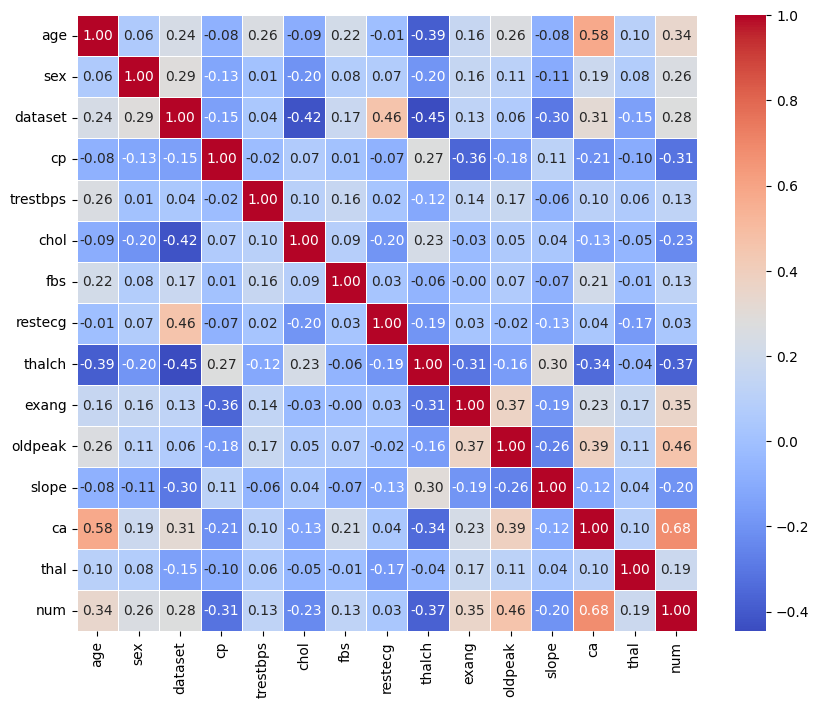

In [12]:
#Plotting the heat map related to the correlated values.
correlation_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [13]:
correlation_values = abs(df.corr()['num'].drop('num')).sort_values(ascending=False)
correlation_values

ca          0.679756
oldpeak     0.460313
thalch      0.372838
exang       0.350567
age         0.339596
cp          0.314518
dataset     0.276203
sex         0.259342
chol        0.233097
slope       0.201875
thal        0.186387
fbs         0.129539
trestbps    0.126096
restecg     0.034603
Name: num, dtype: float64

In [14]:
X = np.asarray(df.iloc[:, :-1])
y = np.asarray(df.iloc[:, -1])
X[:5]

array([[ 63. ,   1. ,   0. ,   3. , 145. , 233. ,   1. ,   0. , 150. ,
          0. ,   2.3,   0. ,   0. ,   0. ],
       [ 67. ,   1. ,   0. ,   0. , 160. , 286. ,   0. ,   0. , 108. ,
          1. ,   1.5,   1. ,   3. ,   1. ],
       [ 67. ,   1. ,   0. ,   0. , 120. , 229. ,   0. ,   0. , 129. ,
          1. ,   2.6,   1. ,   2. ,   2. ],
       [ 37. ,   1. ,   0. ,   2. , 130. , 250. ,   0. ,   1. , 187. ,
          0. ,   3.5,   0. ,   0. ,   1. ],
       [ 41. ,   0. ,   0. ,   1. , 130. , 204. ,   0. ,   0. , 172. ,
          0. ,   1.4,   2. ,   0. ,   1. ]])

In [15]:
#Normalizing the data
X_norm = StandardScaler().fit(X).transform(X)

In [16]:
#Splitting the dataset

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=4)

In [17]:
LR = LogisticRegression(
    class_weight="balanced",
    C=0.5,          # regularization strength
    solver="lbfgs",
    max_iter=3000
    ).fit(X_train, y_train)

In [18]:
y_hat = LR.predict(X_test)
y_hat[:10]

array([1., 1., 0., 0., 3., 1., 0., 1., 0., 2.])

In [19]:
#Checking the accuracy score
accuracy_score(y_test, y_hat)

0.5380434782608695

In [20]:
#Checking through confusion matrix
cm = confusion_matrix(y_test, y_hat)
cm

array([[65,  8,  2,  0,  4],
       [11, 18, 16,  5,  4],
       [ 1,  5,  5,  8,  3],
       [ 0,  2,  9, 10,  4],
       [ 0,  2,  0,  1,  1]])

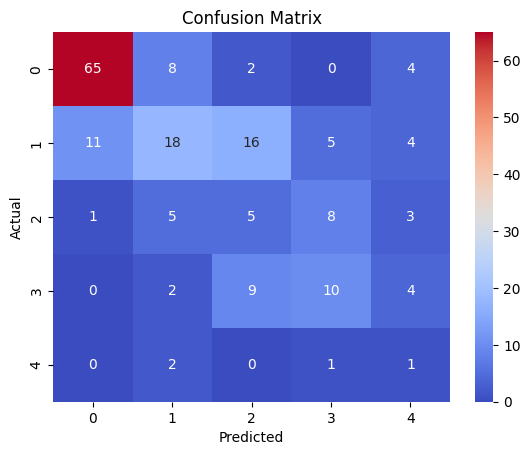

In [21]:
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
y_hat_prob = LR.predict_proba(X_test)
log_loss(y_test, y_hat_prob)

1.2691679848534303

Accuracy Score:
0.6086956521739131


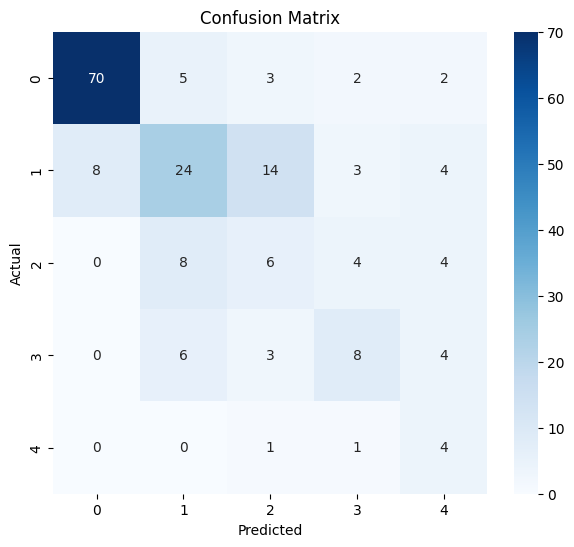


Classification Report:

              precision    recall  f1-score   support

         0.0       0.90      0.85      0.88        82
         1.0       0.56      0.45      0.50        53
         2.0       0.22      0.27      0.24        22
         3.0       0.44      0.38      0.41        21
         4.0       0.22      0.67      0.33         6

    accuracy                           0.61       184
   macro avg       0.47      0.53      0.47       184
weighted avg       0.65      0.61      0.62       184


Log Loss:
1.0764808387271763

Multiclass ROC-AUC Score:
0.852548979668015


In [23]:
#Now training the model again but will less number of features which will affect the model performance. As we could get better accuracy and lesser 
#log loss value.

important_features = [
    "ca",
    "oldpeak",
    "thalch",
    "exang",
    "age",
    "cp",
    "dataset",
    "sex",
    "chol",
]

X = np.asarray(df[important_features])
y = np.asarray(df["num"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    C=1,
    solver="lbfgs"
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:")
print(accuracy)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test_scaled)

loss = log_loss(y_test, y_prob)

print("\nLog Loss:")
print(loss)

auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr"
)

print("\nMulticlass ROC-AUC Score:")
print(auc)

Accuracy Score:
0.8858695652173914


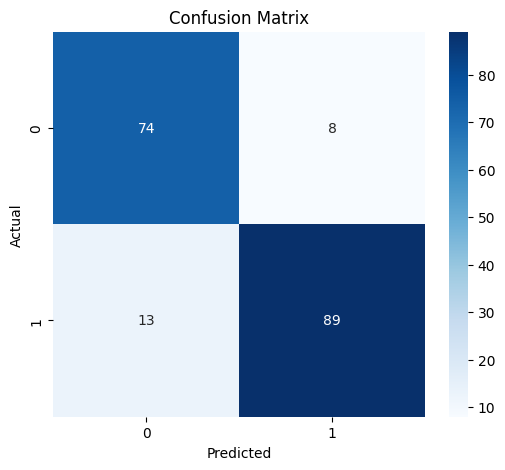


Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.90      0.88        82
           1       0.92      0.87      0.89       102

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



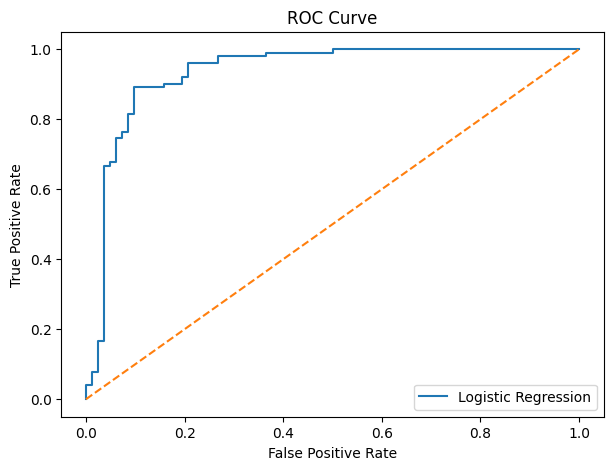


ROC-AUC Score:
0.9338833094213295


In [24]:
# For ROC curve we need binary data so that's why we are converting the target variable from multiclass
# to binary and again traning the model on that and drawing curve.

df["num"] = (df["num"] > 0).astype(int)

X = df.drop("num", axis=1)
y = df["num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    class_weight="balanced",
    max_iter=3000,
    C=1
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:")
print(accuracy)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

auc_score = roc_auc_score(y_test, y_prob)

print("\nROC-AUC Score:")
print(auc_score)

# Highlights

From the classification report of the binary target variable, the results appear to be strong and well-balanced, indicating that the model performs effectively for binary classification. This suggests that the model is capable of distinguishing between the two classes with good precision and recall.

However, when the target variable is treated as multiclass, the performance drops noticeably. This indicates that the model struggles to correctly differentiate between all classes, particularly the minority or more critical class (class 4), which is often the most important in medical prediction tasks. This issue is likely related to class imbalance and the increased complexity of separating multiple labels. Only when the model is trained with class_weight = balanced then it predicts calss 4. Thus balancing is very important.

To improve performance, the model was retrained using a reduced set of important features. This feature selection led to a decrease in log loss and an increase in accuracy, suggesting that removing less relevant features helped the model generalize better. Overall, this indicates that a simpler feature space improved model stability and predictive performance.